In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 6,                # reduced for small figure
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.5,
    "lines.linewidth": 0.6,
    "legend.fontsize": 5.5,
    "legend.title_fontsize": 5.5,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "pdf.fonttype": 42,            # ensures editable text in Illustrator
    "ps.fonttype": 42
})

def make_fixed_axis(axis_size=1.25, label_space=0.15):
    """Create figure with a fixed physical data-area size."""
    figsize = (axis_size + label_space, axis_size + label_space)
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(1, 1)
    ax = fig.add_subplot(gs[0, 0])
    ax.set_box_aspect(1)  # ensures square data region
    return fig, ax

In [6]:
height_ratio = pd.read_excel(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0885\Height change ratio.xlsx", skiprows = 1, sheet_name = "Sheet2")

In [12]:
ratio_WT = height_ratio['Ratio_WT']
ratio_DpgsB = height_ratio['Ratio_DpgsB']
print(ratio_WT, ratio_DpgsB)
height_ratio_mean = [0, 0, np.mean(ratio_DpgsB), np.mean(ratio_WT)]
height_ratio_std = [0, 0, np.std(ratio_DpgsB), np.std(ratio_DpgsB)]

0    1.665103
1    1.254098
2    1.641324
Name: Ratio_WT, dtype: float64 0    0.427673
1    0.584906
2    0.773148
Name: Ratio_DpgsB, dtype: float64


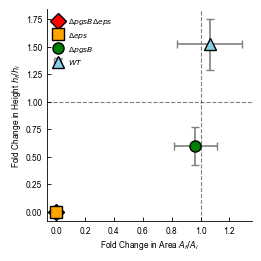

In [11]:
#area data form F0840
area_fold_change = [0, 0, 0, 0, 0, 0, 1.05487608, 0.79043824, 1.04239494, 1.06858124, 1.28761486, 0.83584706]
height_fold_change = [0, 0, 0, 0, 0, 0, 0.427672956, 0.584906, 0.773148148, 1.665103189, 1.254098361, 1.641323792]
data = {
    'Strain': np.repeat([r'$\Delta pgsB \Delta eps$',  r'$\Delta eps$',  r'$\Delta pgsB$', '$WT$'], 3),
    'FoldChange_Area': area_fold_change,
    'FoldChange_Height': height_fold_change,
}
df = pd.DataFrame(data)

strains = df['Strain'].unique()
colors = ['red', 'orange', 'green', 'skyblue']
markers = ['D', 's', 'o', '^']

plt.figure(figsize=(2.5, 2.5))
ax = plt.gca()

for i, strain in enumerate(strains):
    sub_df = df[df['Strain'] == strain]
    mean_x = sub_df['FoldChange_Area'].mean()
    mean_y = sub_df['FoldChange_Height'].mean()
    std_x = sub_df['FoldChange_Area'].std()
    std_y = sub_df['FoldChange_Height'].std()
    ax.errorbar(mean_x, mean_y, xerr=std_x, yerr=std_y,
                color=colors[i],
                fmt=markers[i],
                markersize=8,
                capsize=3,
                lw=1.2,
                ecolor='gray',
                elinewidth=1.2,
                markerfacecolor=colors[i],
                markeredgecolor='black',
                markeredgewidth=1,
                label=strain,
                zorder=5
               )

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)
ax.tick_params(axis='both', direction='in', length=3, width=0.6)

plt.xlabel(r'Fold Change in Area $A_f/A_i$', labelpad=2)
plt.ylabel(r'Fold Change in Height $h_f/h_i$', labelpad=2)
plt.axvline(1, linestyle='--', color='black', alpha=0.5, linewidth=0.8)
plt.axhline(1, linestyle='--', color='black', alpha=0.5, linewidth=0.8)
plt.legend(frameon=False, loc='best', handlelength=1, markerscale=1)
plt.tight_layout(pad=0.5)
plt.show()